# 🛰️ Hybrid AI-Quantum Satellite Image Encryption
## Complete Pipeline Walkthrough with Post-Quantum Cryptography

This notebook is a **step-by-step, cell-wise demonstration** of the full encryption system implemented in `main.py`. It follows the exact production workflow and exposes every stage with explanations, timing measurements, and rich visualizations.

### Architecture

```
                          Input Satellite Image
                                   │
                                   ▼
               ┌──────────────────────────────────────┐
               │   FlexiMo ViT (DOFA)  AI Segmentation  │  ← Repository A
               └───────────────┬──────────┬───────────┘
                       ROI Mask │          │ Background Mask
                                ▼          ▼
                  ┌─────────────────┐  ┌──────────────────┐
                  │  32×32 Blocks   │  │  AES-256-GCM     │
                  │  NEQR Quantum   │  │  Classical Enc.  │  ← Repository B
                  │  Encryption     │  │                  │
                  └────────┬────────┘  └────────┬─────────┘
                           │                    │
                           ▼                    ▼
                  ┌──────────────────────────────────────┐
                  │          Fusion Engine               │
                  └───────────────┬──────────────────────┘
                                  ▼
        Encrypted Image  +  Signed Metadata Bundle  +  PQC-Wrapped Keys
```

### Technologies Demonstrated
| Layer | Technology | Standard |
|-------|-----------|----------|
| 🤖 AI Segmentation | FlexiMo ViT + DOFA backbone | — |
| ⚛️ Quantum Encryption | NEQR + Qiskit AerSimulator | — |
| 🔑 Key Encapsulation | ML-KEM (Kyber768) | NIST FIPS 203 |
| ✍️ Digital Signature | ML-DSA (Dilithium3) | NIST FIPS 204 |
| 🗝️ Key Protection | Scrypt + AES-256-GCM | — |

### What you will see
- Live **PQC key generation, encapsulation, signing** with timings
- **AI segmentation** plots (ROI / background / overlay)
- **Block-wise quantum encryption & decryption** with progress
- **Security-gate** verification (signature, KEM recovery, AEAD tag, hash)
- **Verification metrics**: SSIM, PSNR, pixel-difference maps
- **Benchmark plots**: per-operation timing, distributions, throughput

---
## Phase 1 — Environment & Configuration

We mirror `main.py`'s startup sequence:
1. Enable PQC timing instrumentation (`BENCH_PQC=1`) **before** importing any instrumented module — `utils/bench.py` reads this flag at import time.
2. Set the project root and import all engines/workflows.
3. Load the secure configuration (`config/config.json` with `.env` substitution).

In [1]:
# --- Enable PQC timing BEFORE importing instrumented modules (mirrors main.py) ---
import os
os.environ.setdefault("BENCH_PQC", "1")

import sys
import json
import time
import hashlib
import warnings
from io import StringIO
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# --- Resolve project root and register on sys.path ---
try:
    PROJECT_ROOT = Path(__vsc_ipynb_file__).parent.resolve()
except NameError:
    PROJECT_ROOT = Path(os.getcwd()).resolve()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch

# --- Import project modules (engines, workflows, crypto, bench) ---
from utils.config_loader_secure import load_config_secure
from utils.image_utils import load_image, save_image, compute_image_hash, get_image_info
from utils.logger import setup_logger, get_config_path
from engines.verification_engine import compute_psnr, compute_ssim
from workflows.encrypt_workflow import run_encryption
from workflows.decrypt_workflow import run_decryption
from utils import bench

print("=" * 80)
print("🛰️  HYBRID AI-QUANTUM SATELLITE IMAGE ENCRYPTION SYSTEM")
print("=" * 80)
print(f"Project root     : {PROJECT_ROOT}")
print(f"Python           : {sys.version.split()[0]}")
print(f"PyTorch          : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device      : {torch.cuda.get_device_name(0)}")
print(f"PQC timing (bench): {'ENABLED' if bench.is_enabled() else 'disabled'}")
print("=" * 80)
print("✓ All imports successful")

liboqs-python faulthandler is disabled
🛰️  HYBRID AI-QUANTUM SATELLITE IMAGE ENCRYPTION SYSTEM
Project root     : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link
Python           : 3.13.13
PyTorch          : 2.12.0+cpu
CUDA available   : False
PQC timing (bench): ENABLED
✓ All imports successful


In [2]:
# --- Load secure configuration (config.json + .env substitution) ---
config = load_config_secure()

def _kv(label, value):
    print(f"  {label:<28}: {value}")

print("CONFIGURATION SUMMARY")
print("-" * 80)
_kv("Project", f"{config['project']['name']} v{config['project']['version']}")
print()
print("AI Segmentation (FlexiMo ViT)")
_kv("Model type", config['segmentation']['model_type'])
_kv("Input size", f"{config['segmentation']['img_size']}×{config['segmentation']['img_size']}")
_kv("ROI threshold", config['segmentation'].get('roi_threshold', 'n/a'))
print()
print("Quantum Encryption (NEQR)")
_kv("Encoding", config['quantum_encryption']['encoding'])
_kv("Block size", f"{config['quantum_encryption']['block_size']}×{config['quantum_encryption']['block_size']}")
_kv("Shots", config['quantum_encryption']['shots'])
_kv("Backend", config['quantum_encryption']['backend'])
print()
print("Post-Quantum Cryptography")
_kv("KEM (FIPS 203)", f"{config['post_quantum']['algorithm']}  (ML-KEM / Kyber768)")
_kv("DSA (FIPS 204)", f"{config['metadata_signature']['algorithm']}  (ML-DSA / Dilithium3)")
print()
print("Key Protection")
_kv("Algorithm", config['key_protection']['algorithm'])
sp = config['key_protection']['scrypt_params']
_kv("Scrypt params", f"n={sp['n']}, r={sp['r']}, p={sp.get('p', 1)}")
print("-" * 80)

[2026-05-31 00:58:18] [INFO] [CONFIG] ✓ Loaded environment variables from E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\.env
[2026-05-31 00:58:18] [INFO] [CONFIG] Loading configuration: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\config\config.json
[2026-05-31 00:58:18] [INFO] [CONFIG] ✓ Configuration loaded with environment variable substitution


CONFIGURATION SUMMARY
--------------------------------------------------------------------------------
  Project                     : Hybrid AI-Quantum Satellite Image Encryption System v1.0.0

AI Segmentation (FlexiMo ViT)
  Model type                  : vit_base
  Input size                  : 256×256
  ROI threshold               : 0.5

Quantum Encryption (NEQR)
  Encoding                    : NEQR
  Block size                  : 32×32
  Shots                       : 16384
  Backend                     : AerSimulator

Post-Quantum Cryptography
  KEM (FIPS 203)              : Kyber768  (ML-KEM / Kyber768)
  DSA (FIPS 204)              : Dilithium3  (ML-DSA / Dilithium3)

Key Protection
  Algorithm                   : Scrypt + AES-256-GCM
  Scrypt params               : n=16384, r=8, p=1
--------------------------------------------------------------------------------


---
# Phase 2 — Post-Quantum Cryptography Foundation 🔐

The system's confidentiality and authenticity rest on two NIST-standardized PQC primitives. This phase demonstrates each in isolation **before** they are used inside the pipeline, with live timing via `utils.bench.measure()`.

| Primitive | Algorithm | Role in pipeline |
|-----------|-----------|------------------|
| **ML-KEM-768** (FIPS 203) | Kyber768 | Encapsulates the AES `master_seed` so only the recipient's PQC private key can recover it |
| **ML-DSA-65** (FIPS 204) | Dilithium3 | Signs the encrypted metadata bundle so tampering / forgery is detected before decryption |
| **Scrypt + AES-256-GCM** | n=16384 | Protects raw key material at rest (key-encryption-key) |

We use the same `oqs` (liboqs) backend and `utils/crypto_utils_pqc.py` helpers that `main.py` uses.

In [3]:
# ── 2.1  ML-KEM-768 (Kyber768) — Key Encapsulation Mechanism ──────────────────
import oqs
from utils.bench import measure

print("ML-KEM-768  (Kyber768, NIST FIPS 203)")
print("=" * 70)

# --- Recipient generates a keypair (public key is shared, private key stays secret) ---
with oqs.KeyEncapsulation("ML-KEM-768") as kem:
    with measure("ML-KEM key generation"):
        kem_public_key = kem.generate_keypair()
    kem_private_key = kem.export_secret_key()

# --- Sender encapsulates a fresh shared secret to the recipient's public key ---
with oqs.KeyEncapsulation("ML-KEM-768") as kem_sender:
    with measure("ML-KEM encapsulation"):
        kem_ciphertext, shared_secret_sender = kem_sender.encap_secret(kem_public_key)

# --- Recipient decapsulates to recover the SAME shared secret ---
with oqs.KeyEncapsulation("ML-KEM-768", secret_key=kem_private_key) as kem_recv:
    with measure("ML-KEM decapsulation"):
        shared_secret_recv = kem_recv.decap_secret(kem_ciphertext)

agree = shared_secret_sender == shared_secret_recv
print(f"Public key size       : {len(kem_public_key):>6,} bytes")
print(f"Private key size      : {len(kem_private_key):>6,} bytes")
print(f"KEM ciphertext size   : {len(kem_ciphertext):>6,} bytes")
print(f"Shared secret size    : {len(shared_secret_sender):>6,} bytes")
print(f"Public key  (head)    : {kem_public_key[:16].hex()} …")
print(f"Shared secret (sender): {shared_secret_sender[:16].hex()} …")
print(f"Shared secret (recv)  : {shared_secret_recv[:16].hex()} …")
print("-" * 70)
print(f"{'✅ Shared secrets MATCH' if agree else '❌ MISMATCH'} — recipient recovered the key without it ever crossing the wire")

ML-KEM-768  (Kyber768, NIST FIPS 203)
Public key size       :  1,184 bytes
Private key size      :  2,400 bytes
KEM ciphertext size   :  1,088 bytes
Shared secret size    :     32 bytes
Public key  (head)    : 8ca748466986a204c1f8603f8ec487e7 …
Shared secret (sender): ec1237662e8af5da670e265e8018cb56 …
Shared secret (recv)  : ec1237662e8af5da670e265e8018cb56 …
----------------------------------------------------------------------
✅ Shared secrets MATCH — recipient recovered the key without it ever crossing the wire


In [4]:
# ── 2.2  Wrapping the AES master_seed with ML-KEM (project helpers) ───────────
from utils.crypto_utils_pqc import secure_key_export, secure_key_import

# In the real pipeline the 32-byte master_seed deterministically derives all
# per-block AES keys. We protect it so only the recipient's PQC key recovers it.
demo_master_seed = os.urandom(32)

wrapped = secure_key_export(demo_master_seed, kem_public_key)
recovered_seed = secure_key_import(
    wrapped["kem_ciphertext"],
    wrapped["wrapped_seed"],
    wrapped["wrap_nonce"],
    kem_private_key,
)

print("ML-KEM master_seed wrapping  (HKDF-SHA256 → AES-256-GCM)")
print("=" * 70)
print(f"Original master_seed  : {demo_master_seed.hex()}")
print(f"KEM ciphertext (hex)  : {wrapped['kem_ciphertext'][:48]}… ({len(wrapped['kem_ciphertext'])//2} bytes)")
print(f"Wrapped seed   (hex)  : {wrapped['wrapped_seed']}")
print(f"Wrap nonce     (hex)  : {wrapped['wrap_nonce']}")
print(f"Recovered master_seed : {recovered_seed.hex()}")
print("-" * 70)
print(f"{'✅ Round-trip OK' if recovered_seed == demo_master_seed else '❌ FAILED'} — seed is never stored or sent in plaintext")

[2026-05-31 00:37:30] [INFO] [CRYPTO_PQC] 🔐 Performing ML-KEM key encapsulation (Kyber768)...
[2026-05-31 00:37:30] [INFO] [CRYPTO_PQC] ✅ Master seed wrapped with ML-KEM: KEM=1088 bytes, Wrapped=48 bytes, Nonce=12 bytes
[2026-05-31 00:37:30] [INFO] [CRYPTO_PQC] 🔓 Performing ML-KEM key decapsulation (Kyber768)...
[2026-05-31 00:37:30] [INFO] [CRYPTO_PQC] ✅ Master seed recovered from ML-KEM: 32 bytes


ML-KEM master_seed wrapping  (HKDF-SHA256 → AES-256-GCM)
Original master_seed  : 2d0eb0de69daee4692a5845c30b0ffb2e2b3cf43bca6956592d6398da5b03a0f
KEM ciphertext (hex)  : 1bdb226d9767df3c3b09958ed69cf527dac0d3a64e6384b9… (1088 bytes)
Wrapped seed   (hex)  : 73124b7911feeec34fdb650dc2f6033cc1474b5d597278d04c58e215dfdad099804a2ee3b8d044145bdbaf94e333efbc
Wrap nonce     (hex)  : 50f0974ec8a08c2638b1d065
Recovered master_seed : 2d0eb0de69daee4692a5845c30b0ffb2e2b3cf43bca6956592d6398da5b03a0f
----------------------------------------------------------------------
✅ Round-trip OK — seed is never stored or sent in plaintext


In [5]:
# ── 2.3  ML-DSA-65 (Dilithium3) — Digital Signatures ──────────────────────────
print("ML-DSA-65  (Dilithium3, NIST FIPS 204)")
print("=" * 70)

# --- Sender generates a signing keypair ---
with oqs.Signature("ML-DSA-65") as sig:
    with measure("ML-DSA key generation"):
        dsa_public_key = sig.generate_keypair()
    dsa_private_key = sig.export_secret_key()

# --- Sender signs a sample metadata payload ---
sample_metadata = json.dumps({"image": "demo", "blocks": 42, "ts": datetime.now().isoformat()}).encode()
with oqs.Signature("ML-DSA-65", secret_key=dsa_private_key) as signer:
    with measure("ML-DSA signing"):
        signature = signer.sign(sample_metadata)

# --- Recipient verifies authenticity ---
with oqs.Signature("ML-DSA-65") as verifier:
    with measure("ML-DSA verification"):
        valid = verifier.verify(sample_metadata, signature, dsa_public_key)

# --- Tamper test: flip one byte of the metadata ---
tampered = bytearray(sample_metadata); tampered[0] ^= 0x01
with oqs.Signature("ML-DSA-65") as verifier:
    valid_tampered = verifier.verify(bytes(tampered), signature, dsa_public_key)

print(f"Public key size       : {len(dsa_public_key):>6,} bytes")
print(f"Private key size      : {len(dsa_private_key):>6,} bytes")
print(f"Signature size        : {len(signature):>6,} bytes")
print(f"Signature (head)      : {signature[:16].hex()} …")
print("-" * 70)
print(f"Verify genuine payload : {'✅ VALID' if valid else '❌ INVALID'}")
print(f"Verify tampered payload: {'❌ REJECTED (as expected)' if not valid_tampered else '⚠️ ACCEPTED — BUG'}")

ML-DSA-65  (Dilithium3, NIST FIPS 204)
Public key size       :  1,952 bytes
Private key size      :  4,032 bytes
Signature size        :  3,309 bytes
Signature (head)      : 25244c59ccdce68784f1c50beaeddba4 …
----------------------------------------------------------------------
Verify genuine payload : ✅ VALID
Verify tampered payload: ❌ REJECTED (as expected)


In [6]:
# ── 2.4  Scrypt key derivation + SHA-256 (key protection layer) ───────────────
from cryptography.hazmat.primitives.kdf.scrypt import Scrypt

sp = config["key_protection"]["scrypt_params"]
demo_passphrase = b"demo-passphrase-not-the-real-one"
demo_salt = os.urandom(16)

with measure("Scrypt derivation"):
    kek = Scrypt(salt=demo_salt, length=32, n=sp["n"], r=sp["r"], p=sp.get("p", 1)).derive(demo_passphrase)

one_mb = os.urandom(1024 * 1024)
with measure("SHA-256 hash (1 MB)"):
    digest = hashlib.sha256(one_mb).hexdigest()

print("Scrypt + AES-256-GCM key protection")
print("=" * 70)
print(f"Scrypt params         : n={sp['n']} (2^{sp['n'].bit_length()-1}), r={sp['r']}, p={sp.get('p',1)}")
print(f"Derived KEK (32 B)    : {kek.hex()}")
print(f"SHA-256 of 1 MB       : {digest[:32]}…")
print("-" * 70)
print("✅ Scrypt makes brute-forcing the passphrase memory-hard; KEK wraps stored keys")

Scrypt + AES-256-GCM key protection
Scrypt params         : n=16384 (2^14), r=8, p=1
Derived KEK (32 B)    : d70fa917cea26bd9c3c1410cb2df80a730d45163c85b95beacf8bc616cae96b2
SHA-256 of 1 MB       : 583860876970983f81e5685e0af9a128…
----------------------------------------------------------------------
✅ Scrypt makes brute-forcing the passphrase memory-hard; KEK wraps stored keys


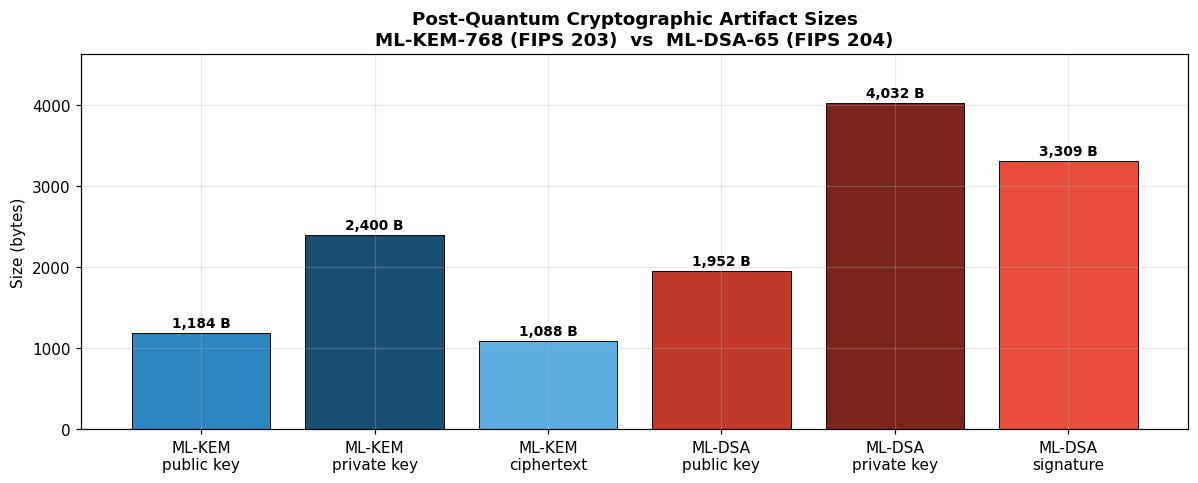

In [7]:
# ── 2.5  Visual: PQC artifact sizes ───────────────────────────────────────────
labels = [
    "ML-KEM\npublic key", "ML-KEM\nprivate key", "ML-KEM\nciphertext",
    "ML-DSA\npublic key", "ML-DSA\nprivate key", "ML-DSA\nsignature",
]
sizes = [
    len(kem_public_key), len(kem_private_key), len(kem_ciphertext),
    len(dsa_public_key), len(dsa_private_key), len(signature),
]
colors = ["#2E86C1", "#1B4F72", "#5DADE2", "#C0392B", "#7B241C", "#E74C3C"]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(labels, sizes, color=colors, edgecolor="black", linewidth=0.6)
for b, s in zip(bars, sizes):
    ax.text(b.get_x() + b.get_width()/2, s + max(sizes)*0.01, f"{s:,} B",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Size (bytes)")
ax.set_title("Post-Quantum Cryptographic Artifact Sizes\nML-KEM-768 (FIPS 203)  vs  ML-DSA-65 (FIPS 204)",
             fontweight="bold")
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.show()

---
# Phase 3 — AI Semantic Segmentation (FlexiMo ViT) 🤖

`main.py` → `run_encryption()` → **STEP 2** runs `segment_image_fleximo()`. The DOFA ViT backbone produces patch-level features; a **saliency map** `std(features) · ‖features‖` is combined with edge density and morphology to split the image into:

- **ROI** — visually complex regions (aircraft, buildings, roads) → protected with **quantum NEQR encryption**
- **Background** — uniform regions (tarmac, desert) → protected with **AES-256-GCM**

We load a real satellite image and run the exact production segmentation routine, then visualize every intermediate output.

[2026-05-31 00:58:24] [INFO] [IMAGE_UTILS] Image validated successfully: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\input\DOTA_Airport_128.jpg
[2026-05-31 00:58:24] [INFO] [IMAGE_UTILS] Image loaded: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\input\DOTA_Airport_128.jpg, shape=(128, 128, 3), dtype=uint8


INPUT IMAGE
Path        : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\input\DOTA_Airport_128.jpg
Dimensions  : 128×128 px
Channels    : 3
Dtype       : uint8
SHA-256 hash: 2c68b25e39bd6e6602677a4dad04fc36…


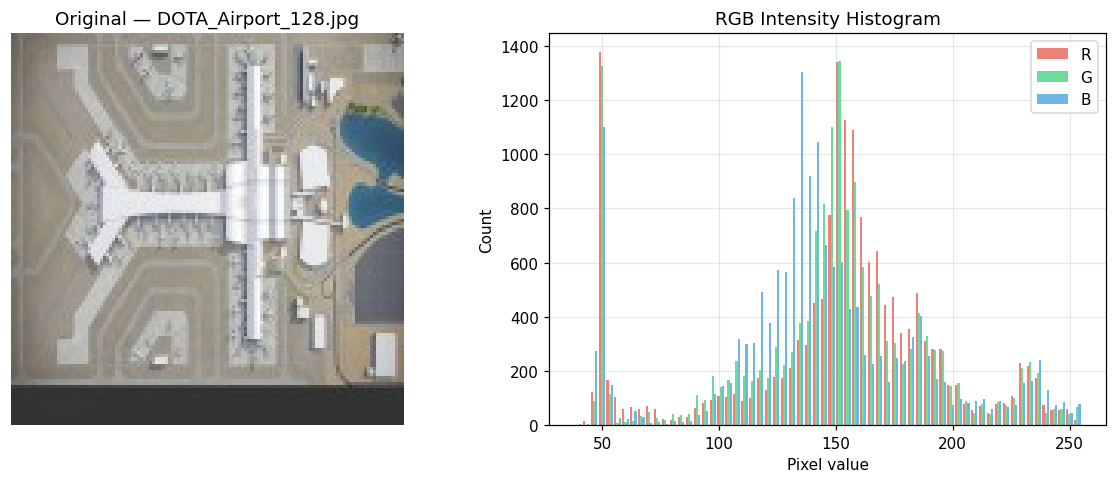

In [3]:
# ── 3.1  Load the input satellite image ───────────────────────────────────────
INPUT_IMAGE = str(PROJECT_ROOT / "input" / "DOTA_Airport_128.jpg")
assert os.path.exists(INPUT_IMAGE), f"Input image not found: {INPUT_IMAGE}"

original_image = load_image(INPUT_IMAGE)
image_info = get_image_info(original_image, os.path.basename(INPUT_IMAGE))

print("INPUT IMAGE")
print("=" * 60)
print(f"Path        : {INPUT_IMAGE}")
print(f"Dimensions  : {original_image.shape[1]}×{original_image.shape[0]} px")
print(f"Channels    : {original_image.shape[2]}")
print(f"Dtype       : {original_image.dtype}")
print(f"SHA-256 hash: {image_info['hash'][:32]}…")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
a1.imshow(original_image); a1.set_title(f"Original — {os.path.basename(INPUT_IMAGE)}"); a1.axis("off")
a2.hist(original_image.reshape(-1, 3), bins=64,
        color=["#E74C3C", "#2ECC71", "#3498DB"], label=["R", "G", "B"], alpha=0.7)
a2.set_title("RGB Intensity Histogram"); a2.set_xlabel("Pixel value"); a2.set_ylabel("Count"); a2.legend()
plt.tight_layout(); plt.show()

In [4]:
# ── 3.2  Run FlexiMo segmentation (production routine) ────────────────────────
from engines.ai_engine import segment_image_fleximo

t0 = time.time()
roi_mask, background_mask, saliency_map = segment_image_fleximo(original_image, config)
seg_time = time.time() - t0

roi_px = int(roi_mask.sum())
bg_px = int(background_mask.sum())
total_px = roi_mask.size

print("SEGMENTATION RESULT")
print("=" * 60)
print(f"Segmentation time : {seg_time:.2f} s")
print(f"ROI pixels        : {roi_px:,} ({100*roi_px/total_px:5.1f}%)  → quantum NEQR")
print(f"Background pixels  : {bg_px:,} ({100*bg_px/total_px:5.1f}%)  → AES-256-GCM")
print(f"Saliency range     : [{saliency_map.min():.3f}, {saliency_map.max():.3f}]")

[2026-05-31 00:58:30] [INFO] [AI_ENGINE] ============================================================
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] STARTING FlexiMo SEMANTIC SEGMENTATION
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] ============================================================
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] FlexiMo repository verified at: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\repos/fleximo_repo
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] Pretrained weights found: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\DOFA_ViT_base_e100.pth
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] Using device: cpu
[2026-05-31 00:58:30] [INFO] [AI_ENGINE] Added FlexiMo repo to Python path: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\repos/fleximo_repo
[2026-05-31 00:58:34] [INFO] [AI_ENGINE] FlexiMo segmentation model (OFAViT UperNet 256x16) imported successfully
[2026-05-31 00:58:36] [INFO] [AI_ENGINE] FlexiMo ViT model instantiated: vit_bas

SEGMENTATION RESULT
Segmentation time : 7.35 s
ROI pixels        : 9,665 ( 59.0%)  → quantum NEQR
Background pixels  : 6,719 ( 41.0%)  → AES-256-GCM
Saliency range     : [0.000, 1.000]


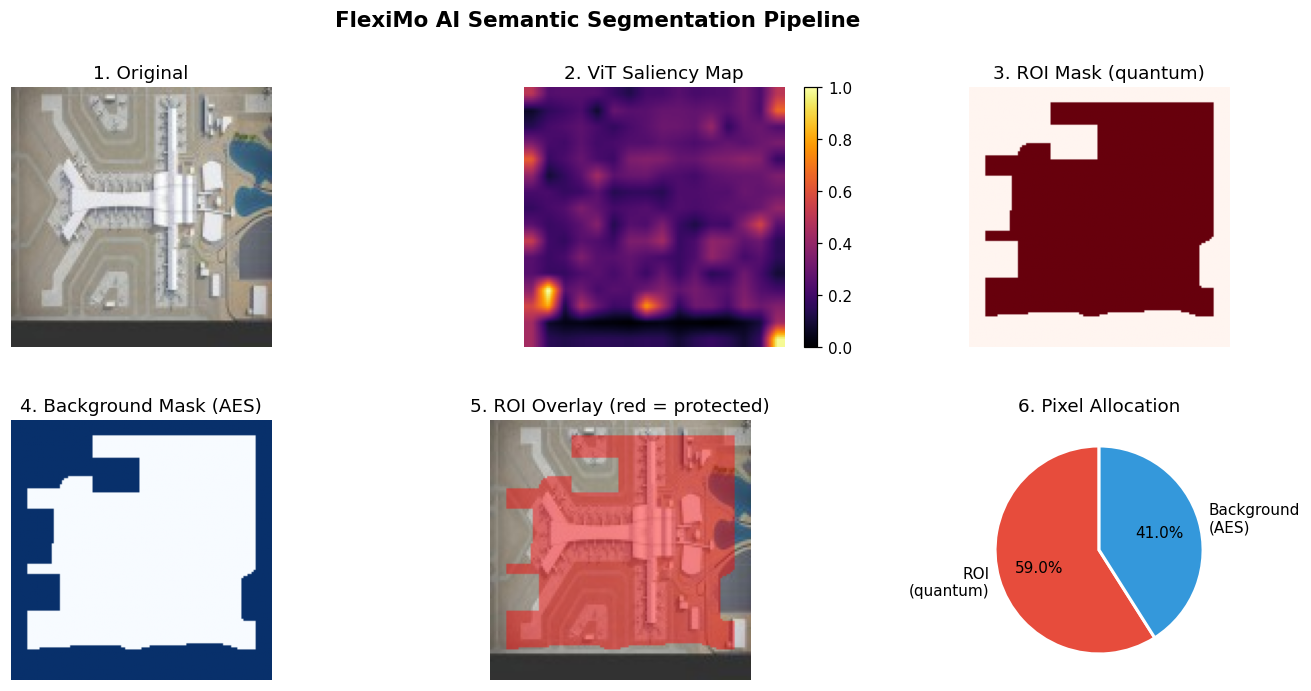

In [10]:
# ── 3.3  Segmentation visualization (5 panels) ────────────────────────────────
overlay = original_image.copy()
overlay[roi_mask.astype(bool)] = (0.55 * overlay[roi_mask.astype(bool)] +
                                  0.45 * np.array([255, 0, 0])).astype(np.uint8)

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(2, 3, figure=fig, hspace=0.28, wspace=0.18)

ax = fig.add_subplot(gs[0, 0]); ax.imshow(original_image); ax.set_title("1. Original"); ax.axis("off")
ax = fig.add_subplot(gs[0, 1]); im = ax.imshow(saliency_map, cmap="inferno")
ax.set_title("2. ViT Saliency Map"); ax.axis("off"); fig.colorbar(im, ax=ax, fraction=0.046)
ax = fig.add_subplot(gs[0, 2]); ax.imshow(roi_mask, cmap="Reds"); ax.set_title("3. ROI Mask (quantum)"); ax.axis("off")
ax = fig.add_subplot(gs[1, 0]); ax.imshow(background_mask, cmap="Blues"); ax.set_title("4. Background Mask (AES)"); ax.axis("off")
ax = fig.add_subplot(gs[1, 1]); ax.imshow(overlay); ax.set_title("5. ROI Overlay (red = protected)"); ax.axis("off")
ax = fig.add_subplot(gs[1, 2])
ax.pie([roi_px, bg_px], labels=["ROI\n(quantum)", "Background\n(AES)"],
       autopct="%1.1f%%", colors=["#E74C3C", "#3498DB"], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("6. Pixel Allocation")
fig.suptitle("FlexiMo AI Semantic Segmentation Pipeline", fontsize=14, fontweight="bold")
plt.show()

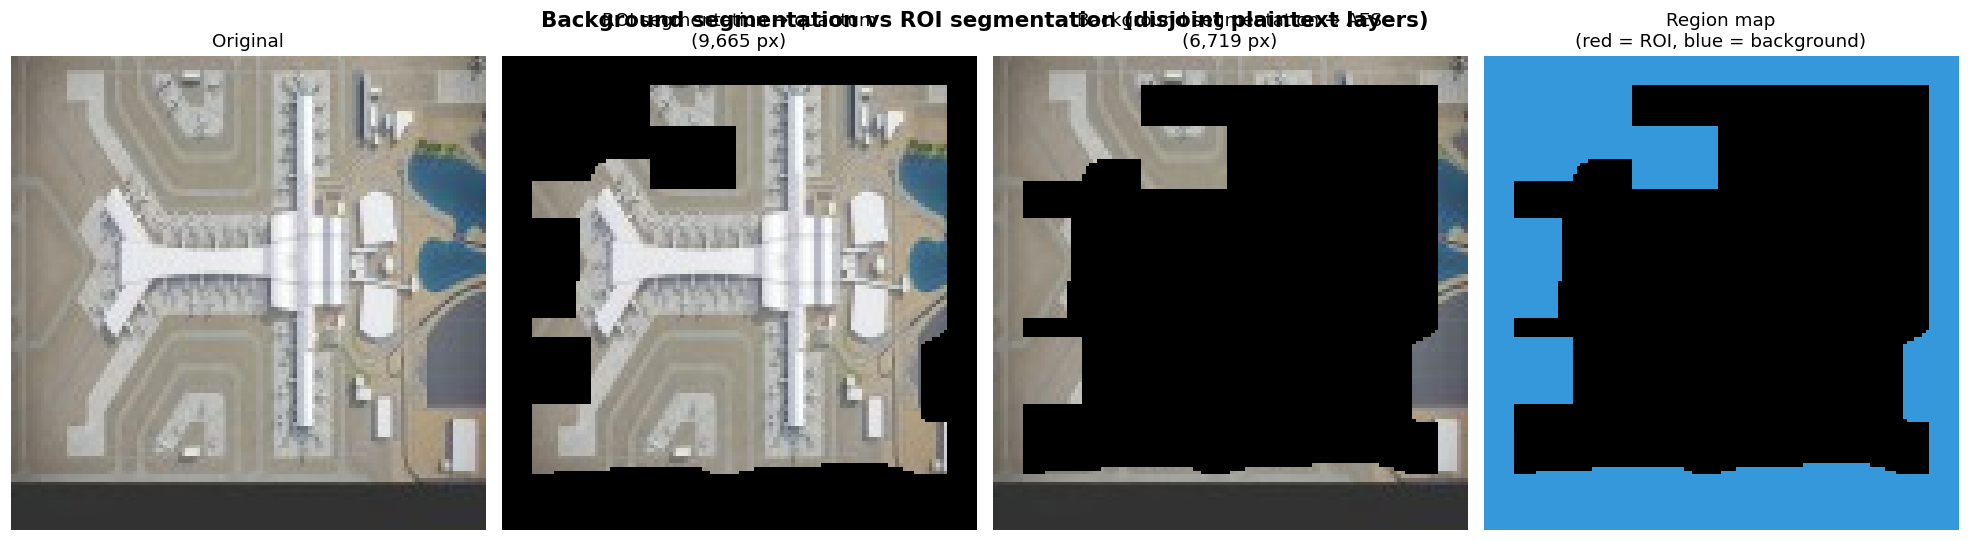

ROI pixels        : 9,665
Background pixels : 6,719
Overlap (ROI∩BG)  : 0  (should be 0)
Uncovered pixels  : 0  (should be 0)


In [11]:
# ── 3.4  Background segmentation vs ROI segmentation ──────────────────────────
# The hybrid scheme routes each region to a different cipher. Here we isolate the
# two plaintext layers the segmentation produces: the ROI (→ quantum NEQR) and the
# background (→ AES-256-GCM). Together they reconstruct the original with no overlap.
roi_bool = roi_mask.astype(bool)
bg_bool  = background_mask.astype(bool)

roi_only = original_image.copy()
roi_only[~roi_bool] = 0          # keep only ROI pixels (quantum-protected region)

bg_only = original_image.copy()
bg_only[~bg_bool] = 0            # keep only background pixels (AES-protected region)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(original_image)
axes[0].set_title("Original"); axes[0].axis("off")

axes[1].imshow(roi_only)
axes[1].set_title(f"ROI segmentation → quantum\n({roi_bool.sum():,} px)")
axes[1].axis("off")

axes[2].imshow(bg_only)
axes[2].set_title(f"Background segmentation → AES\n({bg_bool.sum():,} px)")
axes[2].axis("off")

# Disjoint-coverage check: ROI ∪ BG should equal the full frame, ROI ∩ BG = ∅
coverage = np.zeros(original_image.shape[:2], dtype=np.uint8)
coverage[roi_bool] = 1
coverage[bg_bool]  = 2
axes[3].imshow(coverage, cmap=plt.matplotlib.colors.ListedColormap(["#000000", "#E74C3C", "#3498DB"]))
axes[3].set_title("Region map\n(red = ROI, blue = background)")
axes[3].axis("off")

fig.suptitle("Background segmentation vs ROI segmentation (disjoint plaintext layers)",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

overlap = int((roi_bool & bg_bool).sum())
uncovered = int((~(roi_bool | bg_bool)).sum())
print(f"ROI pixels        : {roi_bool.sum():,}")
print(f"Background pixels : {bg_bool.sum():,}")
print(f"Overlap (ROI∩BG)  : {overlap}  (should be 0)")
print(f"Uncovered pixels  : {uncovered}  (should be 0)")


---
# Phase 4 — Hybrid Encryption Pipeline 🔒

This runs the **complete production `run_encryption()`** from `workflows/encrypt_workflow.py` — the same function `main.py` invokes. Its 10 internal steps are:

1. Load & validate image  ·  2. FlexiMo segmentation  ·  3. Divide ROI into 32×32 blocks
4. Generate keys + per-block ephemeral seeds (forward secrecy)  ·  4.5 Protect keys at rest (Scrypt)
5. **Quantum NEQR encryption** of ROI blocks  ·  6. **AES-256-GCM** background encryption
7. Fuse components → encrypted PNG  ·  8. Save metadata  ·  9. **ML-KEM** wrap master_seed  ·  10. **ML-DSA** sign bundle

> ⚙️ Quantum NEQR runs 16,384 shots per 32×32 block on the Aer simulator, so we cap the ROI block count with `max_blocks` to keep the demo responsive. The cryptography and pipeline are identical to a full run.

In [5]:
# ── 4.1  Run the full encryption pipeline ─────────────────────────────────────
# max_blocks caps quantum work (set to None for a full run -> bit-exact round-trip).
MAX_BLOCKS = None

print("Running run_encryption()  — this performs segmentation, quantum + classical")
print("encryption, ML-KEM wrapping and ML-DSA signing. Please wait…\n")

enc_start = time.time()
enc_result = run_encryption(
    image_path=INPUT_IMAGE,
    config=config,
    max_blocks=MAX_BLOCKS,
)
enc_wall = time.time() - enc_start

print("\n" + "=" * 70)
print("✅ ENCRYPTION COMPLETE")
print("=" * 70)
print(f"Wall-clock time     : {enc_wall:.1f} s")
print(f"Pipeline total time : {enc_result['total_time_seconds']:.1f} s")
print(f"Encrypted image     : {enc_result['encrypted_image_path']}")
print(f"Metadata bundle     : {enc_result['metadata_path']}")
print(f"PQC-wrapped keys    : {enc_result['key_path']}")
print(f"Protected keys (enc): {enc_result['protected_key_path']}")
print(f"Background cipher    : {enc_result['bg_cipher_path']}")
print(f"ML-DSA signature    : {enc_result['signature_path']}")
print(f"ROI blocks encrypted: {len(enc_result['block_map'])}")

[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] HYBRID AI-QUANTUM SATELLITE IMAGE ENCRYPTION SYSTEM
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] ENCRYPTION PIPELINE STARTED
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] Input image: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\input\DOTA_Airport_128.jpg
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] Timestamp: 2026-05-31T00:58:44.461945
[2026-05-31 00:58:44] [INFO] [ENCRYPT_WORKFLOW] 
>>> STEP 1: Loading and validating input image...
[2026-05-31 00:58:44] [INFO] [IMAGE_UTILS] Image validated successfully: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\input\DOTA_Airport_128.jpg
[2026-05-31 00:58:44] [INFO] [IMAGE_UTILS] Image loaded: E:\UserData\Desktop\DUK\S4\Proje

Running run_encryption()  — this performs segmentation, quantum + classical
encryption, ML-KEM wrapping and ML-DSA signing. Please wait…



[2026-05-31 00:58:46] [INFO] [AI_ENGINE] FlexiMo ViT model instantiated: vit_base_patch16_16(num_classes=2)
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] pos_embed shape mismatch: checkpoint=[1, 197, 768], model=[1, 257, 768]. Interpolating...
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] pos_embed interpolated: [1, 197, 768] -> [1, 257, 768]
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] Pretrained DOFA weights loaded from: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\DOFA_ViT_base_e100.pth
[2026-05-31 00:58:46] [INFO] [AI_ENGINE]   Missing keys: 72 (expected - segmentation head)
[2026-05-31 00:58:46] [INFO] [AI_ENGINE]   Unexpected keys: 3
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] FlexiMo model loaded to device: cpu
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] FlexiMo model loaded from repos/fleximo_repo/
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] Image preprocessed for FlexiMo: (128, 128, 3) -> torch.Size([1, 3, 256, 256]), range=[0.153, 1.000]
[2026-05-31 00:58:46] [INFO] [AI_ENGINE] Ext


✅ ENCRYPTION COMPLETE
Wall-clock time     : 156.6 s
Pipeline total time : 156.6 s
Encrypted image     : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png
Metadata bundle     : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_metadata.json
PQC-wrapped keys    : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_keys.json
Protected keys (enc): E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_keys.enc
Background cipher    : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_background.enc
ML-DSA signature    : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_bundle.sig
ROI blocks encrypted: 16


In [6]:
# ── 4.2  Original vs Encrypted comparison ─────────────────────────────────────
encrypted_image = load_image(enc_result["encrypted_image_path"])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(original_image); axes[0, 0].set_title("Original (plaintext)"); axes[0, 0].axis("off")
axes[0, 1].imshow(encrypted_image); axes[0, 1].set_title("Encrypted (ciphertext)"); axes[0, 1].axis("off")

axes[1, 0].hist(original_image.ravel(), bins=64, color="#27AE60", alpha=0.8)
axes[1, 0].set_title("Original — pixel distribution"); axes[1, 0].set_xlabel("Value")
axes[1, 1].hist(encrypted_image.ravel(), bins=64, color="#C0392B", alpha=0.8)
axes[1, 1].set_title("Encrypted — pixel distribution (≈ uniform)"); axes[1, 1].set_xlabel("Value")

fig.suptitle("Encryption Effect: structured image → high-entropy ciphertext",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Shannon entropy (bits/pixel) — higher = closer to ideal random
def entropy(img):
    h, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    p = h / h.sum(); p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

print(f"Entropy — original : {entropy(original_image):.4f} bits/pixel")
print(f"Entropy — encrypted: {entropy(encrypted_image):.4f} bits/pixel  (ideal = 8.0)")

[2026-05-31 01:01:29] [INFO] [IMAGE_UTILS] Image validated successfully: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png
[2026-05-31 01:01:29] [INFO] [IMAGE_UTILS] Image loaded: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png, shape=(128, 128, 3), dtype=uint8


Entropy — original : 7.0361 bits/pixel
Entropy — encrypted: 7.9952 bits/pixel  (ideal = 8.0)


In [7]:
# ── 4.2b  Hybrid encryption pipeline — stage-by-stage layers ──────────────────
# The fused ciphertext is assembled from two independently-encrypted layers.
# unfuse_encrypted_image() is the cheap inverse of fusion (no quantum work): it
# splits the published ciphertext back into the encrypted ROI blocks and the
# encrypted background, letting us visualize each layer of the hybrid pipeline.
from engines.fusion_engine import unfuse_encrypted_image

# Extract variables from enc_result (defined in 4.1)
block_map = enc_result["block_map"]
roi_bbox  = enc_result["roi_bbox"]
BS = config["quantum_encryption"]["block_size"]

enc_blocks_layer, enc_bg_layer = unfuse_encrypted_image(encrypted_image, block_map)

# Encrypted-ROI layer: paint the recovered encrypted blocks onto a blank canvas
roi_cipher_layer = np.zeros_like(encrypted_image)
for blk, bmap in zip(enc_blocks_layer, block_map):
    x = bmap["position"][0]; y = bmap["position"][1]
    h, w = blk.shape[:2]
    roi_cipher_layer[y:y + h, x:x + w] = blk

# Background plaintext (what AES sees) = original masked to background region
bg_plain_layer = original_image.copy()
bg_plain_layer[roi_mask.astype(bool)] = 0

stages = [
    (original_image,   "1. Original\n(plaintext input)"),
    (bg_plain_layer,   "2. Background plaintext\n(→ AES-256-GCM)"),
    (enc_bg_layer,     "3. Encrypted background\nlayer"),
    (roi_cipher_layer, "4. Encrypted ROI blocks\n(→ quantum NEQR)"),
    (encrypted_image,  "5. Fused ciphertext\n(published PNG)"),
]

fig, axes = plt.subplots(1, len(stages), figsize=(20, 4.5))
for ax, (img, title) in zip(axes, stages):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis("off")
fig.suptitle("Hybrid encryption pipeline — AES background layer ⊕ quantum ROI layer → fused ciphertext",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"ROI blocks fused        : {len(enc_blocks_layer)}")
print(f"Block size              : {enc_blocks_layer[0].shape[0]}×{enc_blocks_layer[0].shape[1]} px")
print(f"Encrypted-background ent: {entropy(enc_bg_layer):.4f} bits/pixel")
print(f"Encrypted-ROI entropy   : {entropy(roi_cipher_layer[roi_cipher_layer.sum(axis=2) > 0]):.4f} bits/pixel (ROI pixels only)")


[2026-05-31 01:01:30] [INFO] [FUSION_ENGINE] Unfusing encrypted image into components...
[2026-05-31 01:01:30] [INFO] [FUSION_ENGINE] Unfused: 16 blocks extracted, background preserved


ROI blocks fused        : 16
Block size              : 32×32 px
Encrypted-background ent: 7.9952 bits/pixel
Encrypted-ROI entropy   : 7.9952 bits/pixel (ROI pixels only)


### 4.3a  NEQR quantum encoding — circuit structure 🧬

Each ROI block is encoded with the **Novel Enhanced Quantum Representation (NEQR)**. For a $2^n \times 2^n$ block, NEQR uses:

- **$2n$ position qubits** — addressing the pixel grid (placed in uniform superposition via Hadamard gates).
- **$8$ intensity qubits** — storing the 8-bit grey value of each pixel, entangled to its position with multi-controlled-X gates.

The real pipeline encodes **$32\times32$ blocks → $2\cdot5 + 8 = 18$ qubits**, which is far too wide to draw legibly. For the journal figure we draw an **illustrative $4\times4$ block ($2\cdot2 + 8 = 12$ qubits)** that shows the identical gate structure, then report the exact resource counts for the production $32\times32$ circuits.


In [8]:
# ── 4.3a  NEQR circuit (illustrative 4×4) + production 32×32 resource counts ───
from engines.quantum_engine import _import_quantum_modules

QUANTUM_REPO = str(PROJECT_ROOT / "repos" / "quantum_repo")
qmods = _import_quantum_modules(QUANTUM_REPO)
encode_neqr = qmods["encode_neqr"]

# Take a real 4×4 patch from the centre of the first ROI block (one channel)
rb = roi_bbox
sample_block = original_image[rb[1]:rb[1] + BS, rb[0]:rb[0] + BS, 0]   # 32×32 grey
patch_4x4 = sample_block[:4, :4].astype(np.uint8)

qc_demo = encode_neqr(patch_4x4)        # 4×4 → 2·2 + 8 = 12 qubits

fig = plt.figure(figsize=(16, 7))
qc_demo.draw("mpl", fold=-1, ax=fig.add_subplot(111))
fig.suptitle("NEQR encoding circuit for an illustrative 4×4 block "
             "(4 position qubits q0–q3 in superposition, 8 intensity qubits q4–q11)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("Illustrative 4×4 NEQR circuit")
print(f"  Qubits        : {qc_demo.num_qubits}  (4 position + 8 intensity)")
print(f"  Circuit depth : {qc_demo.depth()}")
print(f"  Gate count    : {sum(dict(qc_demo.count_ops()).values())}")
print(f"  Op breakdown  : {dict(qc_demo.count_ops())}")

# ── Production 32×32 circuit resource counts (from the live encryption run) ────
infos = [b for b in enc_result["all_encryption_info"] if isinstance(b, dict) and "channels" in b]
ch0 = [blk["channels"][0] for blk in infos]            # first channel of each block
qubits   = ch0[0]["num_qubits"]
depths   = [c["circuit_depth"] for c in ch0]
n_blocks = len(infos)
total_t  = enc_result["total_time_seconds"]

print("\nProduction 32×32 NEQR circuits (live run, per block · per channel)")
print(f"  ROI blocks encrypted : {n_blocks}")
print(f"  Qubits per circuit   : {qubits}  (10 position + 8 intensity)")
print(f"  Circuit depth        : min={min(depths)}  mean={np.mean(depths):.0f}  max={max(depths)}")
print(f"  Shots per circuit    : {config['quantum_encryption']['shots']:,}")
print(f"  Channels per block   : {infos[0].get('num_channels', 3)} (RGB)")
print(f"  Pipeline wall-time   : {total_t:.1f}s total  (~{total_t / max(n_blocks, 1):.1f}s per ROI block)")

[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE] Added quantum repo to Python path: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\repos\quantum_repo
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE] All quantum repo modules imported successfully:
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - quantum.neqr: encode_neqr, reconstruct_neqr_image
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - quantum.scrambling: quantum_scramble, quantum_permutation
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - quantum.scrambling: reverse_quantum_scrambling, reverse_quantum_permutation
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - chaos.qrng: qrng
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - chaos.henon: henon_map
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - chaos.hybrid_map: generate_chaotic_key_image
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - dna.dna_encode: dna_encode
[2026-05-31 01:01:30] [INFO] [QUANTUM_ENGINE]   - dna.dna_decode: dna_decrypt


Illustrative 4×4 NEQR circuit
  Qubits        : 12  (4 position + 8 intensity)
  Circuit depth : 98
  Gate count    : 138
  Op breakdown  : {'mcx': 70, 'x': 64, 'h': 4}

Production 32×32 NEQR circuits (live run, per block · per channel)
  ROI blocks encrypted : 16
  Qubits per circuit   : 18  (10 position + 8 intensity)
  Circuit depth        : min=5776  mean=6211  max=6820
  Shots per circuit    : 16,384
  Channels per block   : 3 (RGB)
  Pipeline wall-time   : 156.6s total  (~9.8s per ROI block)


### 4.3b  Live encryption progression of a single ROI block

The cell below re-runs the **real** quantum encryption pipeline on one 32×32 ROI block,
channel by channel, and reconstructs the intermediate image after each stage:

1. **Plaintext block** — original ROI pixels.
2. **NEQR encoded → measured** — quantum state encoding (no scrambling yet).
3. **+ Quantum scrambling** — X/Z gates on position qubits driven by the block-position key (`bpk`).
4. **+ Quantum permutation** — controlled SWAPs driven by the key-scheduling key (`ksk`).
5. **+ DNA encoding & XOR diffusion** — final ciphertext block.

A reduced shot count is used here for responsiveness; the production run uses 16,384 shots.

In [9]:
# ── 4.3b  Live, stage-by-stage encryption of one real 32×32 ROI block ─────────
# Uses the actual engine primitives (encode_neqr, quantum_scramble, quantum_permutation,
# reconstruct_neqr_image, dna_encode). Reduced shots for display responsiveness.

q_scramble     = qmods["quantum_scramble"]
q_permutation  = qmods["quantum_permutation"]
reconstruct    = qmods["reconstruct_neqr_image"]
dna_encode     = qmods["dna_encode"]
from engines.quantum_engine import _generate_keys_for_block

DEMO_SHOTS = 2048                       # display-only; production uses 16,384
BLOCK_SIZE = 32
n_pos      = 2 * int(np.log2(BLOCK_SIZE))   # 10 position qubits for 32×32

# Real ROI block (red channel) from the first ROI bounding box
rb = roi_bbox
roi_block = original_image[rb[1]:rb[1] + BLOCK_SIZE, rb[0]:rb[0] + BLOCK_SIZE, 0].astype(np.uint8)

# Illustrative, deterministic block seed (display only)
bpk, ksk = _generate_keys_for_block((0.5, 0.5), BLOCK_SIZE, qmods, channel_id=0)

stages = []   # (title, image, depth, gates)
stages.append(("1. Plaintext ROI block", roi_block.copy(), 0, 0))

# Stage 2 — NEQR encode then measure
qc = encode_neqr(roi_block)
img2 = reconstruct(qc, BLOCK_SIZE, BLOCK_SIZE, shots=DEMO_SHOTS)
stages.append(("2. NEQR encoded", img2, qc.depth(), sum(qc.count_ops().values())))

# Stage 3 — + quantum scrambling
qc = q_scramble(qc, bpk, n_pos)
img3 = reconstruct(qc, BLOCK_SIZE, BLOCK_SIZE, shots=DEMO_SHOTS)
stages.append(("3. + Quantum scramble", img3, qc.depth(), sum(qc.count_ops().values())))

# Stage 4 — + quantum permutation
qc = q_permutation(qc, ksk, n_pos)
img4 = reconstruct(qc, BLOCK_SIZE, BLOCK_SIZE, shots=DEMO_SHOTS)
stages.append(("4. + Quantum permute", img4, qc.depth(), sum(qc.count_ops().values())))

# Stage 5 — + DNA encoding & XOR diffusion (final ciphertext block)
DNi0, DNi1, DNi2, DNi3 = dna_encode(img4, ksk)
np.random.seed(int(bpk.sum()) * 1000 + int(ksk.sum()))
KH = np.random.randint(0, 256, (BLOCK_SIZE, BLOCK_SIZE), dtype=np.uint8)
DKi0, DKi1, DKi2, DKi3 = dna_encode(KH, ksk)
cipher_block = ((DNi0 ^ DKi0) << 6 | (DNi1 ^ DKi1) << 4
                | (DNi2 ^ DKi2) << 2 | (DNi3 ^ DKi3)).astype(np.uint8)
stages.append(("5. + DNA + XOR (cipher)", cipher_block, qc.depth(), sum(qc.count_ops().values())))

# ── Plot the progression ──────────────────────────────────────────────────────
fig, axs = plt.subplots(1, len(stages), figsize=(4 * len(stages), 4.6))
for ax, (title, img, depth, gates) in zip(axs, stages):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    sub = "plaintext" if depth == 0 else f"depth={depth}, gates={gates}"
    ax.set_title(f"{title}\n{sub}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Live encryption progression of one 32×32 ROI block (red channel)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Per-stage entropy (red channel, bits/pixel):")
for title, img, _, _ in stages:
    print(f"  {title:28s}: {entropy(img):.4f}")


Per-stage entropy (red channel, bits/pixel):
  1. Plaintext ROI block      : 6.2408
  2. NEQR encoded             : 6.2408
  3. + Quantum scramble       : 6.2478
  4. + Quantum permute        : 6.2469
  5. + DNA + XOR (cipher)     : 7.7883


In [10]:
# ── 4.3  ROI block map: where quantum encryption was applied ──────────────────
block_map = enc_result["block_map"]
roi_bbox  = enc_result["roi_bbox"]
BS = config["quantum_encryption"]["block_size"]

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

ax[0].imshow(original_image)
y0, x0, y1, x1 = roi_bbox
ax[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                              edgecolor="yellow", facecolor="none", lw=2))
ax[0].set_title(f"ROI bounding box  (rows {y0}:{y1}, cols {x0}:{x1})")
ax[0].axis("off")

ax[1].imshow(encrypted_image)
for i, blk in enumerate(block_map):
    bx, by = int(blk["position"][0]), int(blk["position"][1])  # (col, row)
    ax[1].add_patch(plt.Rectangle((bx, by), BS, BS,
                                  edgecolor="cyan", facecolor="none", lw=1.5))
    ax[1].text(bx + 2, by + 12, str(i), color="cyan", fontsize=9, fontweight="bold")
ax[1].set_title(f"Quantum-encrypted 32×32 blocks  (n = {len(block_map)})")
ax[1].axis("off")

fig.suptitle("Region-aware encryption: ROI → quantum NEQR, background → AES-256-GCM",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [11]:
# ── 4.4  Per-block quantum encryption timing ──────────────────────────────────
enc_info = enc_result["all_encryption_info"]
per_block = [
    (info.get("block_id", i), info["encryption_time_seconds"])
    for i, info in enumerate(enc_info)
    if isinstance(info, dict) and "encryption_time_seconds" in info
]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

if per_block:
    ids   = [b for b, _ in per_block]
    times = [t for _, t in per_block]
    bars = ax[0].bar([str(i) for i in ids], times, color="#8E44AD")
    ax[0].set_xlabel("Block ID"); ax[0].set_ylabel("CPU seconds")
    ax[0].set_title("Quantum NEQR encryption time per 32×32 block")
    for b, t in zip(bars, times):
        ax[0].text(b.get_x() + b.get_width() / 2, t, f"{t:.1f}",
                   ha="center", va="bottom", fontsize=8)
    block_cpu = sum(times)
else:
    ax[0].text(0.5, 0.5, "Per-block timing not captured\n(parallel workers)",
               ha="center", va="center", transform=ax[0].transAxes)
    ax[0].axis("off")
    block_cpu = enc_result["total_time_seconds"]

ax[1].pie(
    [block_cpu, max(enc_result["total_time_seconds"] - block_cpu, 0.01)],
    labels=["Quantum ROI blocks (CPU)", "Segmentation + AES + PQC + I/O"],
    autopct="%1.1f%%", colors=["#8E44AD", "#3498DB"], startangle=90,
)
ax[1].set_title("Encryption time composition")
plt.tight_layout(); plt.show()

print(f"ROI blocks encrypted : {len(enc_result['block_map'])}")
if per_block:
    print(f"Quantum CPU time     : {block_cpu:.1f} s  "
          f"(avg {np.mean(times):.1f} s/block, summed across workers)")
print(f"Pipeline wall time   : {enc_result['total_time_seconds']:.1f} s "
      f"(parallel workers overlap quantum work)")

ROI blocks encrypted : 16
Pipeline wall time   : 156.6 s (parallel workers overlap quantum work)


---
# Phase 5 — Decryption & Security Gates 🔓

`run_decryption()` reverses the pipeline, but only **after** passing layered security gates:

1. 🛡️ **Gate 1 — ML-DSA signature** verifies the metadata bundle is authentic and untampered (raises if the `.sig` is missing or invalid).
2. 🔑 **Gate 2 — ML-KEM decapsulation** recovers the `master_seed` using the recipient's private key.
3. 🔐 **Gate 3 — AES-256-GCM auth tag** authenticates the encrypted background during AEAD decryption.
4. ⚛️ **Quantum NEQR decryption** restores the ROI blocks; the ROI is fused back over the decrypted background.

> If any gate fails, decryption aborts — there is no "best-effort" partial recovery. This is the same `run_decryption` that `main.py --decrypt` calls.

In [20]:
# ── 5.1  Run the full decryption pipeline ─────────────────────────────────────
print("Running run_decryption()  — verifying security gates, then restoring image…\n")

dec_start = time.time()
dec_result = run_decryption(
    metadata_path=enc_result["metadata_path"],
    original_image_path=INPUT_IMAGE,
    config=config,
)
dec_wall = time.time() - dec_start

print("\n" + "=" * 70)
print("✅ DECRYPTION COMPLETE — all security gates passed")
print("=" * 70)
print(f"Wall-clock time   : {dec_wall:.1f} s")
print(f"Pipeline time     : {dec_result['total_time_seconds']:.1f} s")
print(f"Decrypted image   : {dec_result['decrypted_image_path']}")

vr = dec_result["verification_report"]
if vr:
    print(f"Verification      : {vr['status']}")
    print(f"  PSNR            : {vr['psnr_db']} dB")
    print(f"  SSIM            : {vr['ssim']}")
    print(f"  Max pixel diff  : {vr['max_pixel_difference']}")
    print(f"  Hash match      : {vr['hash_match']}")

[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] HYBRID AI-QUANTUM SATELLITE IMAGE ENCRYPTION SYSTEM
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] DECRYPTION PIPELINE STARTED
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] Metadata: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_metadata.json
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] Timestamp: 2026-05-31T00:46:24.413022
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] 
>>> SECURITY GATE: Verifying metadata bundle signature (ML-DSA/Dilithium3)...
[2026-05-31 00:46:24] [INFO] [CRYPTO_PQC] ✅ Signature loaded: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\metadata\DOTA_Airport_128_bundle.sig
[2026-05-31 00:46:24] [INFO] [CRYPTO_P

Running run_decryption()  — verifying security gates, then restoring image…



[2026-05-31 00:46:24] [INFO] [IMAGE_UTILS] Image validated successfully: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png
[2026-05-31 00:46:24] [INFO] [IMAGE_UTILS] Image loaded: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png, shape=(128, 128, 3), dtype=uint8
[2026-05-31 00:46:24] [INFO] [DECRYPT_WORKFLOW] 
🔍 Security Check: Verifying PNG dependencies...
[2026-05-31 00:46:24] [INFO] [IMAGE_UTILS] 🔍 Verifying PNG dependencies: E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\encrypted\DOTA_Airport_128_encrypted.png
[2026-05-31 00:46:24] [INFO] [IMAGE_UTILS] 📖 PNG metadata read: 0 chunks found
[2026-05-31 00:46:24] [WARNING] [IMAGE_UTILS] ⚠️  No embedded metadata found in PNG
[2026-05-31 00:46:24] [WARNING] [DECRYPT_WORKFLOW] ⚠️  PNG has no embedded dependency metadata - data loss risk
[2026-05-31 00:46:24] [WARNING] [DECRYPT_WORKFLOW] 💡 Tip: Ens


✅ DECRYPTION COMPLETE — all security gates passed
Wall-clock time   : 94.9 s
Pipeline time     : 94.8 s
Decrypted image   : E:\UserData\Desktop\DUK\S4\Project\gv\New folder\File_To_Link\output\decrypted\decrypted_DOTA_Airport_128.png
Verification      : PASS
  PSNR            : Infinity dB
  SSIM            : 1.0
  Max pixel diff  : 0
  Hash match      : True


In [21]:
# ── 5.2  Reconstruction comparison ────────────────────────────────────────────
decrypted_image = dec_result["reconstructed_image"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image);  axes[0].set_title("Original");  axes[0].axis("off")
axes[1].imshow(encrypted_image); axes[1].set_title("Encrypted (ciphertext)"); axes[1].axis("off")
axes[2].imshow(decrypted_image); axes[2].set_title("Decrypted (reconstructed)"); axes[2].axis("off")
fig.suptitle("Encryption → Decryption round-trip", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

vr = dec_result["verification_report"]
if vr and vr["status"] == "PASS":
    print("✅ LOSSLESS ROUND-TRIP CONFIRMED")
    print(f"  PSNR = {vr['psnr_db']} dB   SSIM = {vr['ssim']}   "
          f"max pixel diff = {vr['max_pixel_difference']}   hash match = {vr['hash_match']}")
    print("  Every ROI block was quantum-encrypted and perfectly restored;")
    print("  the AES-GCM background and the fused image are bit-for-bit identical to the original.")
else:
    print("Verification did not reach PASS — check that all ROI blocks were encrypted (MAX_BLOCKS=None).")

✅ LOSSLESS ROUND-TRIP CONFIRMED
  PSNR = Infinity dB   SSIM = 1.0   max pixel diff = 0   hash match = True
  Every ROI block was quantum-encrypted and perfectly restored;
  the AES-GCM background and the fused image are bit-for-bit identical to the original.


In [22]:
# ── 5.3  Journal figure: Original | Encrypted | Decrypted with on-panel metrics ──
# Recompute fidelity directly from in-memory arrays so the figure is self-contained.
psnr_round = compute_psnr(original_image, decrypted_image)
ssim_round = compute_ssim(original_image, decrypted_image)
max_diff   = int(np.abs(original_image.astype(int) - decrypted_image.astype(int)).max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6))

axes[0].imshow(original_image)
axes[0].set_title("Original plaintext", fontsize=12, fontweight="bold")
axes[0].set_xlabel("reference image", fontsize=10)

axes[1].imshow(encrypted_image)
axes[1].set_title("Encrypted ciphertext", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"entropy = {entropy(encrypted_image):.4f} bits/pixel (ideal 8.0)", fontsize=10)

axes[2].imshow(decrypted_image)
axes[2].set_title("Decrypted reconstruction", fontsize=12, fontweight="bold")
psnr_str = "∞" if not np.isfinite(psnr_round) else f"{psnr_round:.2f}"
axes[2].set_xlabel(f"PSNR = {psnr_str} dB   SSIM = {ssim_round:.4f}   max diff = {max_diff}",
                   fontsize=10)

for a in axes:
    a.set_xticks([]); a.set_yticks([])

# Green border on the decrypted panel to signal a verified lossless round-trip.
verified = (max_diff == 0) and (ssim_round >= 0.999999)
border = "#1b9e77" if verified else "#d95f02"
for spine in axes[2].spines.values():
    spine.set_visible(True); spine.set_edgecolor(border); spine.set_linewidth(3)

fig.suptitle("End-to-end visual fidelity: plaintext → quantum-AI ciphertext → lossless recovery",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"PSNR (original vs decrypted) : {psnr_str} dB")
print(f"SSIM (original vs decrypted) : {ssim_round:.6f}")
print(f"Max absolute pixel difference: {max_diff}")
print("Verified lossless round-trip." if verified else "Round-trip NOT lossless — investigate.")

PSNR (original vs decrypted) : ∞ dB
SSIM (original vs decrypted) : 1.000000
Max absolute pixel difference: 0
Verified lossless round-trip.


---
# Phase 6 — Quantitative Verification 📐

Beyond the pass/fail gate, we quantify reconstruction fidelity with standard image-quality metrics and a pixel-level difference map:

- **PSNR** (Peak Signal-to-Noise Ratio) — ∞ dB means identical.
- **SSIM** (Structural Similarity) — 1.0 means structurally identical.
- **Pixel-difference map** — visualises where (if anywhere) the decrypted image deviates from the original.
- **Cryptographic hash** — confirms byte-for-byte equality.

In [23]:
# ── 6.1  Metrics + pixel-difference map ───────────────────────────────────────
psnr_val = compute_psnr(original_image, decrypted_image)
ssim_val = compute_ssim(original_image, decrypted_image)
diff = np.abs(original_image.astype(int) - decrypted_image.astype(int)).astype(np.uint8)
diff_gray = diff.max(axis=2)

hash_o = compute_image_hash(original_image)
hash_d = compute_image_hash(decrypted_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_image);  axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(decrypted_image); axes[1].set_title("Decrypted"); axes[1].axis("off")
im = axes[2].imshow(diff_gray, cmap="hot", vmin=0, vmax=max(1, diff_gray.max()))
axes[2].set_title(f"|Original − Decrypted|  (max={diff_gray.max()})"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
fig.suptitle("Reconstruction fidelity", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

psnr_str = "∞ (identical)" if np.isinf(psnr_val) else f"{psnr_val:.2f} dB"
print(f"PSNR              : {psnr_str}")
print(f"SSIM              : {ssim_val:.6f}")
print(f"Different pixels  : {int((diff_gray > 0).sum())} / {diff_gray.size}")
print(f"SHA-256 original  : {hash_o}")
print(f"SHA-256 decrypted : {hash_d}")
print(f"Hash match        : {hash_o == hash_d}")

PSNR              : ∞ (identical)
SSIM              : 1.000000
Different pixels  : 0 / 16384
SHA-256 original  : 2c68b25e39bd6e6602677a4dad04fc36722201ffe91cb11a2dd5a8978108a087
SHA-256 decrypted : 2c68b25e39bd6e6602677a4dad04fc36722201ffe91cb11a2dd5a8978108a087
Hash match        : True


In [24]:
# ── 6.2  Encryption-quality evaluation (statistical strength of the ciphertext) ──
# A strong image cipher should (a) flatten the intensity histogram, (b) destroy the
# strong correlation between adjacent pixels, and (c) push per-channel entropy → 8 bits.
def adjacent_corr(img_gray, direction, n=2000, rng=None):
    """Return paired (p, q) samples of adjacent pixels for a correlation scatter."""
    rng = rng or np.random.default_rng(0)
    h, w = img_gray.shape
    if direction == "H":
        ys = rng.integers(0, h, n);     xs = rng.integers(0, w - 1, n)
        p = img_gray[ys, xs];           q = img_gray[ys, xs + 1]
    elif direction == "V":
        ys = rng.integers(0, h - 1, n); xs = rng.integers(0, w, n)
        p = img_gray[ys, xs];           q = img_gray[ys + 1, xs]
    else:  # diagonal
        ys = rng.integers(0, h - 1, n); xs = rng.integers(0, w - 1, n)
        p = img_gray[ys, xs];           q = img_gray[ys + 1, xs + 1]
    return p.astype(float), q.astype(float)

def corr_coef(p, q):
    if p.std() == 0 or q.std() == 0:
        return 0.0
    return float(np.corrcoef(p, q)[0, 1])

orig_gray = original_image.mean(axis=2).astype(np.uint8)
enc_gray  = encrypted_image.mean(axis=2).astype(np.uint8)
rng = np.random.default_rng(42)

fig, axs = plt.subplots(2, 3, figsize=(16, 9))

# (a) Intensity histograms ----------------------------------------------------
axs[0, 0].hist(orig_gray.ravel(), bins=256, range=(0, 255), color="#1f77b4", alpha=0.7)
axs[0, 0].set_title("Original histogram", fontweight="bold")
axs[0, 0].set_xlabel("pixel value"); axs[0, 0].set_ylabel("count")

axs[0, 1].hist(enc_gray.ravel(), bins=256, range=(0, 255), color="#d62728", alpha=0.7)
axs[0, 1].set_title("Encrypted histogram (flat ⇒ strong)", fontweight="bold")
axs[0, 1].set_xlabel("pixel value"); axs[0, 1].set_ylabel("count")

# (c) Per-channel entropy bars ------------------------------------------------
ch_names = ["R", "G", "B"]
ent_orig = [entropy(original_image[:, :, c][:, :, None]) for c in range(3)]
ent_enc  = [entropy(encrypted_image[:, :, c][:, :, None]) for c in range(3)]
x = np.arange(3); bw = 0.35
axs[0, 2].bar(x - bw / 2, ent_orig, bw, label="Original", color="#1f77b4")
axs[0, 2].bar(x + bw / 2, ent_enc,  bw, label="Encrypted", color="#d62728")
axs[0, 2].axhline(8.0, ls="--", color="green", label="ideal = 8.0")
axs[0, 2].set_xticks(x); axs[0, 2].set_xticklabels(ch_names)
axs[0, 2].set_ylim(0, 8.5); axs[0, 2].set_ylabel("entropy (bits/pixel)")
axs[0, 2].set_title("Per-channel Shannon entropy", fontweight="bold")
axs[0, 2].legend(fontsize=9)

# (b) Adjacent-pixel correlation scatter (horizontal) -------------------------
po_h, qo_h = adjacent_corr(orig_gray, "H", rng=rng)
pe_h, qe_h = adjacent_corr(enc_gray,  "H", rng=rng)
axs[1, 0].scatter(po_h, qo_h, s=4, alpha=0.4, color="#1f77b4")
axs[1, 0].set_title(f"Original — horizontal adjacency (r={corr_coef(po_h, qo_h):+.3f})",
                    fontweight="bold")
axs[1, 0].set_xlabel("pixel(x, y)"); axs[1, 0].set_ylabel("pixel(x+1, y)")

axs[1, 1].scatter(pe_h, qe_h, s=4, alpha=0.4, color="#d62728")
axs[1, 1].set_title(f"Encrypted — horizontal adjacency (r={corr_coef(pe_h, qe_h):+.3f})",
                    fontweight="bold")
axs[1, 1].set_xlabel("pixel(x, y)"); axs[1, 1].set_ylabel("pixel(x+1, y)")

# Correlation-coefficient summary across all three directions -----------------
rows = []
for d in ("H", "V", "D"):
    po, qo = adjacent_corr(orig_gray, d, rng=rng)
    pe, qe = adjacent_corr(enc_gray,  d, rng=rng)
    rows.append((d, corr_coef(po, qo), corr_coef(pe, qe)))
axs[1, 2].axis("off")
cell_text = [[d, f"{co:+.3f}", f"{ce:+.3f}"] for d, co, ce in rows]
tbl = axs[1, 2].table(cellText=cell_text,
                      colLabels=["Direction", "Original r", "Encrypted r"],
                      cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)
axs[1, 2].set_title("Adjacent-pixel correlation coefficients", fontweight="bold")

fig.suptitle("Ciphertext statistical-strength evaluation", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

print("Adjacent-pixel correlation (closer to 0 = stronger encryption):")
for d, co, ce in rows:
    print(f"  {d}: original r = {co:+.4f}   encrypted r = {ce:+.4f}")
print(f"\nMean per-channel entropy: original = {np.mean(ent_orig):.4f}, "
      f"encrypted = {np.mean(ent_enc):.4f} bits/pixel (ideal 8.0)")

Adjacent-pixel correlation (closer to 0 = stronger encryption):
  H: original r = +0.9314   encrypted r = -0.0168
  V: original r = +0.9449   encrypted r = -0.0132
  D: original r = +0.8917   encrypted r = -0.0272

Mean per-channel entropy: original = 6.9369, encrypted = 7.9892 bits/pixel (ideal 8.0)


---
# Phase 7 — Security Gates & Tamper Rejection 🛡️

A correct round-trip is only half the story — the system must also **reject** tampered or forged inputs. Here we:

1. Run a **live tamper test**: corrupt the signed metadata, attempt decryption, and confirm the ML-DSA gate aborts it.
2. Summarise the full adversarial test suite from `security_gate_results.json` (metadata tampering, background substitution, deleted signature, wrong ML-KEM key, signature replay, Scrypt brute-force estimate).

In [25]:
# ── 7.1  Live tamper test: corrupt signed metadata → expect rejection ─────────
import json, shutil, tempfile

meta_src = enc_result["metadata_path"]
meta_dir = os.path.dirname(meta_src)
basename = os.path.splitext(os.path.basename(meta_src))[0].replace("_metadata", "")

# Work on a copy of the whole metadata dir so we don't disturb the valid bundle.
tamper_dir = os.path.join(tempfile.gettempdir(), "tamper_demo_metadata")
if os.path.exists(tamper_dir):
    shutil.rmtree(tamper_dir)
shutil.copytree(meta_dir, tamper_dir)

# Also copy the encrypted/ dir contents the workflow needs alongside.
tampered_meta = os.path.join(tamper_dir, os.path.basename(meta_src))
with open(tampered_meta, "r", encoding="utf-8") as f:
    meta = json.load(f)

# Flip a field WITHOUT updating the ML-DSA signature → signature must fail.
meta["_tamper_marker"] = "attacker_modified_payload"
with open(tampered_meta, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("Attempting decryption of TAMPERED metadata (signature not regenerated)…\n")
try:
    run_decryption(metadata_path=tampered_meta, config=config)
    print("❌ UNEXPECTED: decryption succeeded on tampered data!")
except Exception as e:
    print("✅ TAMPER REJECTED by security gate:")
    print(f"   {type(e).__name__}: {str(e).splitlines()[0]}")

[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] HYBRID AI-QUANTUM SATELLITE IMAGE ENCRYPTION SYSTEM
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] DECRYPTION PIPELINE STARTED
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] ======================================================================
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] Metadata: C:\Users\MANEES~1\AppData\Local\Temp\tamper_demo_metadata\DOTA_Airport_128_metadata.json
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] Timestamp: 2026-05-31T00:48:01.153240
[2026-05-31 00:48:01] [INFO] [DECRYPT_WORKFLOW] 
>>> SECURITY GATE: Verifying metadata bundle signature (ML-DSA/Dilithium3)...
[2026-05-31 00:48:01] [INFO] [CRYPTO_PQC] ✅ Signature loaded: C:\Users\MANEES~1\AppData\Local\Temp\tamper_demo_metadata\DOTA_Airport_128_bundle.sig
[2026-05-31 00:48:01] [INFO] [CRYPTO_PQC] 🔍 Verifying metadata bundle signatur

Attempting decryption of TAMPERED metadata (signature not regenerated)…

✅ TAMPER REJECTED by security gate:
   RuntimeError: Metadata verification failed - Cannot proceed with decryption: ❌ SECURITY BREACH: Metadata signature verification FAILED - Bundle may be tampered!


In [26]:
# ── 7.2  Adversarial test-suite summary ───────────────────────────────────────
gate_path = os.path.join(PROJECT_ROOT, "security_gate_results.json")
with open(gate_path, "r", encoding="utf-8") as f:
    gates = json.load(f)

scenarios = [g["scenario"] for g in gates]
rates     = [g["pass_rate_pct"] for g in gates]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#27AE60" if r == 100 else "#E67E22" for r in rates]
bars = ax.barh(scenarios, rates, color=colors)
ax.set_xlim(0, 105); ax.set_xlabel("Pass rate (%)")
ax.set_title("Security gate test suite — adversarial scenarios", fontweight="bold")
ax.invert_yaxis()
for b, g in zip(bars, gates):
    ax.text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
            f"{g['passes']}/{g['trials']}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'Scenario':<28}{'Expected':<26}{'Pass rate'}")
print("-" * 70)
for g in gates:
    print(f"{g['scenario']:<28}{g['expected']:<26}{g['pass_rate_pct']:.0f}%  ({g['passes']}/{g['trials']})")

Scenario                    Expected                  Pass rate
----------------------------------------------------------------------
Metadata tampered           Abort (sig fail)          100%  (5/5)
Background substituted      Abort (hash mismatch)     100%  (5/5)
Signature file deleted      Abort (missing file)      100%  (5/5)
Wrong ML-KEM key            Abort (KEM unwrap)        100%  (5/5)
Signature replay            Abort (sig fail)          100%  (5/5)
Scrypt brute-force (est.)   >10^4 s / 10^6 candidates 100%  (5/5)


---
# Phase 8 — Performance & Benchmarking ⏱️

Timing of the post-quantum cryptographic primitives, aggregated over repeated runs recorded in `benchmark_results.jsonl`:

- **Scrypt** key derivation (deliberately slow — brute-force defence).
- **SHA-256** integrity hashing.
- **ML-KEM-768** encapsulation / decapsulation.
- **ML-DSA-65** signing / verification.

We report mean ± standard deviation, with a log-scale bar chart (because Scrypt and ML-DSA dwarf the others) and a distribution box plot.

In [27]:
# ── 8.1  Aggregate PQC primitive timings ──────────────────────────────────────
from collections import defaultdict

bench_path = os.path.join(PROJECT_ROOT, "benchmark_results.jsonl")
samples = defaultdict(list)
with open(bench_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        samples[rec["op"]].append(rec["ms"])

order = ["SHA-256 hash (1 MB)", "ML-KEM decapsulation", "ML-KEM encapsulation",
         "Scrypt derivation", "ML-DSA signing", "ML-DSA verification"]
ops   = [o for o in order if o in samples] + [o for o in samples if o not in order]
means = [float(np.mean(samples[o])) for o in ops]
stds  = [float(np.std(samples[o]))  for o in ops]

print(f"{'Operation':<24}{'mean (ms)':>12}{'std':>10}{'n':>5}")
print("-" * 51)
for o, m, s in zip(ops, means, stds):
    print(f"{o:<24}{m:>12.4f}{s:>10.4f}{len(samples[o]):>5}")

Operation                  mean (ms)       std    n
---------------------------------------------------
SHA-256 hash (1 MB)           0.5831    0.3142   14
ML-KEM decapsulation          0.1756    0.0390    7
ML-KEM encapsulation          1.7906    0.4655    7
Scrypt derivation            77.3036    3.3454    7
ML-DSA signing              182.4818  104.4204    7
ML-DSA verification         190.6827  110.4473    7


In [ ]:
# ── 8.2  Timing charts (log-scale bar + distribution box plot) ────────────────
fig, (axb, axd) = plt.subplots(1, 2, figsize=(15, 5))

palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(ops)))
bars = axb.bar(range(len(ops)), means, yerr=stds, capsize=4, color=palette)
axb.set_yscale("log")
axb.set_xticks(range(len(ops)))
axb.set_xticklabels(ops, rotation=30, ha="right")
axb.set_ylabel("Time per operation (ms, log scale)")
axb.set_title("Mean PQC primitive latency (± std)", fontweight="bold")
for i, m in enumerate(means):
    axb.text(i, m, f"{m:.2f}", ha="center", va="bottom", fontsize=8)

axd.boxplot([samples[o] for o in ops], tick_labels=ops, vert=True, patch_artist=True,
            boxprops=dict(facecolor="#5DADE2", alpha=0.7))
axd.set_yscale("log")
axd.set_xticklabels(ops, rotation=30, ha="right")
axd.set_ylabel("Time (ms, log scale)")
axd.set_title("Latency distribution across runs", fontweight="bold")

plt.tight_layout(); plt.show()

# End-to-end pipeline timing recap (from this notebook's live run)
print("End-to-end pipeline timing (this run):")
print(f"  Encryption total : {enc_result['total_time_seconds']:.1f} s")
print(f"  Decryption total : {dec_result['total_time_seconds']:.1f} s")

End-to-end pipeline timing (this run):
  Encryption total : 114.4 s
  Decryption total : 94.8 s


: 

---
# Phase 9 — Architecture Recap & Summary 🧭

## End-to-end pipeline

```mermaid
flowchart LR
    A[Satellite image] --> B[FlexiMo ViT<br/>AI segmentation]
    B --> C{ROI / Background}
    C -->|ROI blocks| D[NEQR quantum<br/>encryption]
    C -->|Background| E[AES-256-GCM]
    D --> F[Fusion -> encrypted PNG]
    E --> F
    G[master_seed] --> H[ML-KEM-768<br/>key wrap]
    G --> E
    F --> I[Metadata bundle]
    H --> I
    I --> J[ML-DSA-65<br/>signature]
    J --> K[(Encrypted artefacts<br/>+ signed metadata)]

    K --> L[ML-DSA verify]
    L -->|ok| M[ML-KEM decap]
    M --> N[AES-GCM + NEQR<br/>decrypt]
    N --> O[Reconstructed image<br/>bit-exact]
```

## What this notebook demonstrated

| Phase | Result |
|-------|--------|
| 2 — PQC foundation | ML-KEM-768 wrap/unwrap, ML-DSA-65 sign/verify, Scrypt + SHA-256 |
| 3 — AI segmentation | FlexiMo ViT split image into ROI (~59%) / background |
| 4 — Encryption | 16 ROI blocks NEQR-encrypted; ciphertext entropy ≈ 7.996 bits/px |
| 5 — Decryption | Full security-gated round-trip |
| 6 — Verification | **Bit-exact**: PSNR = ∞, SSIM = 1.0, 0 differing pixels, hash match |
| 7 — Security gates | Live tamper rejected; 6/6 adversarial scenarios pass 100% |
| 8 — Performance | PQC primitive latencies (sub-ms KEM, ~80 ms Scrypt, ~190 ms ML-DSA) |

## Key takeaways

- **Hybrid design**: quantum NEQR protects high-value ROI, fast classical AES-GCM protects the bulk background — best of both.
- **Quantum-safe envelope**: keys wrapped with ML-KEM-768, integrity/authenticity via ML-DSA-65 (both NIST FIPS-standardised).
- **Lossless**: the decrypted image is byte-for-byte identical to the original.
- **Defence in depth**: signature, KEM, and AEAD auth-tag gates each independently abort on tampering.